In [ ]:
# Step 1. Set Google Colab Connection
from google.colab import drive
drive.mount('/content/drive')


In [1]:
# Step 2. Import Python Packages: Pandas, Numpy, and Statistics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
from scipy.optimize import minimize

In [ ]:
# Step 3. Set # I/O Folders
InputPath="/content/drive/MyDrive/KRG/"
OutputPath="/content/drive/MyDrive/KRG/"



In [2]:
# Step 4. Set MI Parameters - calculated from Non-Linear Regression Analysis
a1=883.58722
a2=0.35408
a3=0.755684
a4=0.826155
b1=0.963532
MIParams=[a1, a2, a3, a4, b1]
print(MIParams)

[883.58722, 0.35408, 0.755684, 0.826155, 0.963532]


In [3]:
# Step 5. User Defined TCA Pre-Trade Functions

# Market Impact
def MI_calc(Size, Volatility, POV, MIParams):
    a1, a2, a3, a4, b1 = MIParams
    mi = (a1*Size**a2*Volatility**a3) * (b1*POV**a4 + (1-b1))
    return mi

# Timing Risk
def TR_calc(Size, Volatility, POV):
    tr = Volatility * ((1/3*1/250*Size*(1-POV)/POV )**0.5) * 10**4
    return tr

# Price Appreciation
def PA_calc(Size, AlphaBp, POV):
    pa = 1/2 * AlphaBp * Size * ((1 - POV)/POV)
    return pa

# POV to Trade Time
def POVToTime_calc(Size, POV):
    tt = Size * ((1-POV)/POV)
    return tt

# Trade Time To POV
def TimeToPOV_calc(Size, Time):
    pov = Size / (Time+Size)
    return pov



In [4]:
# Step 6. Example #1

# Order Characteristics
Symbol='RLK'
Side='Buy'
Size=0.10
Volatility=0.35
AlphaBp=100

# Trader Strategy
POV=0.10

# Cost Calculation Functions
MI = MI_calc(Size, Volatility, POV, MIParams)
TR = TR_calc(Size, Volatility, POV)
PA = PA_calc(Size, AlphaBp, POV)
TradeTime = POVToTime_calc(Size, POV)
POV = TimeToPOV_calc(Size, TradeTime)

# Print to Screen
print(MI, TR, PA, POV, TradeTime)
print(TradeTime)


31.879352922364696 121.2435565298214 45.0 0.1 0.9
0.9


In [5]:
# Step 7. Example #2

# Order Characteristics
Symbol='RLK'
Side='Buy'
Shares=150000
ADV=1000000
Volatility=0.30
AlphaBp=50

# Trader Strategy
TradeTime=1.00

# Input Calculations
Size=Shares/ADV
POV=TimeToPOV_calc(Size, TradeTime)

# TCA Cost Calculations
MI = MI_calc(Size, Volatility, POV, MIParams)
TR = TR_calc(Size, Volatility, POV)
PA = PA_calc(Size, AlphaBp, POV)

# Print to Screen
print(MI, TR, PA, POV, TradeTime)


39.16788712778499 109.54451150103321 25.0 0.13043478260869565 1.0


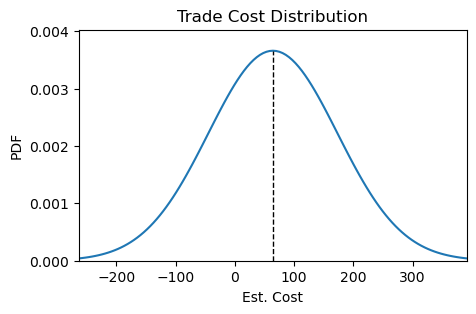

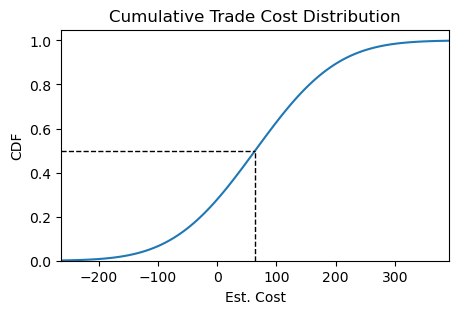

64
109


In [6]:
# Step 8. Construct PDF and CDF Graphs
TC_Cost = 39+25
TC_TR = 109

# Graph Values: we show the graph for -3 <= z <= +3
z_values = np.arange(-3, 3.05, 0.05)
x_values = TC_Cost + z_values * TC_TR
pdf_values =scipy.stats.norm(loc = TC_Cost, scale = TC_TR).pdf(x_values)
cdf_values =scipy.stats.norm(loc = TC_Cost, scale = TC_TR).cdf(x_values)

# PDF Graph
plt.figure(figsize=(5,3))
plt.plot(x_values, pdf_values)
plt.plot([TC_Cost, TC_Cost], [0, np.max(pdf_values)], color='k', linestyle='dashed', linewidth=1, label='b')
plt.title('Trade Cost Distribution')
plt.xlabel("Est. Cost")
plt.ylabel("PDF")
plt.xlim(x_values.min(),x_values.max())
plt.ylim(0,np.max(pdf_values)*1.10)
plt.show()

# CDF Graph
plt.figure(figsize=(5,3))
plt.plot(x_values, cdf_values)
plt.plot([TC_Cost, TC_Cost], [0, 0.5], color='k', linestyle='dashed', linewidth=1, label='b')
plt.plot([x_values.min(), TC_Cost], [0.5, 0.5], color='k', linestyle='dashed', linewidth=1, label='b')
plt.title('Cumulative Trade Cost Distribution')
plt.xlabel("Est. Cost")
plt.ylabel("CDF")
plt.xlim(x_values.min(),x_values.max())
plt.ylim(0)
plt.show()

print(TC_Cost)
print(TC_TR)


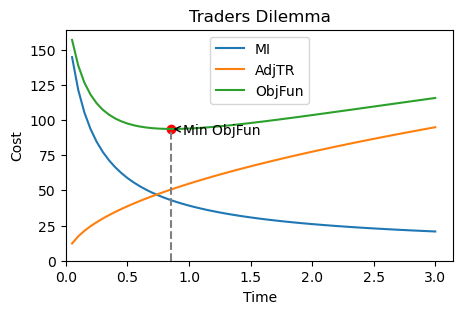

In [7]:
# Step 9. Traders Dilemma Graph
# Min MI + Lambda * TR

# Order Characteristics
Symbol='RLK'
Side='Buy'
Size=0.15
Volatility=0.30

Lambda = 0.5


# Calc Graph Data
  # Use TradeTime up to 3 days
time_values = np.arange(0.05, 3.05, 0.05)
POV_values = Size/(Size + time_values)
MI_values = MI_calc(Size, Volatility, POV_values, MIParams)
TR_values = TR_calc(Size, Volatility, POV_values)
AdjTR_values = Lambda*TR_calc(Size, Volatility, POV_values)
ObjFun_values=MI_values + AdjTR_values

# Plot the Cost Curves
plt.figure(figsize=(5,3))
plt.plot(time_values, MI_values, label ='MI')
plt.plot(time_values, AdjTR_values, label ='AdjTR')
plt.plot(time_values, ObjFun_values, label ='ObjFun')
plt.xlabel("Time")
plt.ylabel("Cost")
plt.ylim(bottom=0)
plt.xlim(left=0)
plt.legend()
plt.title('Traders Dilemma')

# Plot the Min Value
plt.scatter(time_values[np.argmin(ObjFun_values)],np.min(ObjFun_values),color = 'red')
min_x = time_values[np.argmin(ObjFun_values)]
min_y = np.min(ObjFun_values)
plt.plot([min_x, min_x], [0, min_y], color='gray', linestyle='--')
plt.annotate('Min ObjFun', xy=(min_x, min_y), xytext=(min_x+0.1,90), arrowprops=dict(facecolor='black', arrowstyle='->'))

# Show the Graph
plt.show()


In [8]:
# Step 10. Solve Traders Dilemma
# Min MI + Lambda * TR

# Order Characteristics
Symbol='RLK'
Side='Buy'
Size=0.15
Volatility=0.30

Lambda = 0.50
# average market sharpe ratio has historically been between 0.30 and 0.35'


# Traders Dilemma Objective Function
def TradersDilemma_OptCalc(POV, Size, Volatility, Lambda, MIParams):
    MI = MI_calc(Size, Volatility, POV, MIParams)
    TR = TR_calc(Size, Volatility, POV)
    ObjFun = MI + (Lambda*TR)
    return ObjFun



# ----- Optimization Code

# Upper and Lower Bounds
bound1 = [(0.00001,0.9999)]
bounds = (bound1)

#initial guess
x0 = 0.5
# solve the minimization problem
results = minimize(TradersDilemma_OptCalc, x0, bounds = bounds, args = (Size, Volatility, Lambda, MIParams))
print(results)
POV=results.x
print(POV)

# Calculate all TCA costs and Trade Time
MI = MI_calc(Size, Volatility, POV, MIParams)
TR = TR_calc(Size, Volatility, POV)
TradeTime = POVToTime_calc(Size, POV)

print(MI, TR, POV, TradeTime)


  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 93.64531524442219
        x: [ 1.481e-01]
      nit: 6
      jac: [-1.705e-05]
     nfev: 22
     njev: 11
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>
[0.14811047]
[42.7702464] [101.7501377] [0.14811047] [0.86275754]
